In [ ]:
# # Exploratory Data Analysis - Lab Exercise (Student Version)
# ## Lab Objective
# Perform comprehensive exploratory data analysis on a retail sales dataset to understand customer purchasing behavior and identify key insights.
# ## Dataset Description
# **Filename:** `retail_sales.csv`
# **Columns:**
# - transaction_id: Unique identifier for each transaction
# - date: Transaction date
# - customer_id: Unique customer identifier
# - age: Customer age
# - gender: Customer gender (Male/Female)
# - product_category: Category of product purchased
# - quantity: Number of items purchased
# - price_per_unit: Price of single unit
# - total_amount: Total transaction amount


In [ ]:

## Required Libraries
# ```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
import plotly.express as px
from scipy.stats import ttest_ind
from scipy import stats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print(" to avoid uploading every time runtime is reloaded  , we reupload the csv file to drive  ")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 to avoid uploading every time runtime is reloaded  , we reupload the csv file to drive  


In [ ]:

## Part 1: Data Loading and Initial Exploration (15 points)

### Task 1.1: Load and Display Data
# Load the dataset and display:
# - First 10 rows
# - Basic dataset information using `.info()`
# - Dataset shape (number of rows and columns)
# - Column names and their data types
print("Load and Display Data")

df=pd.read_csv('/content/drive/MyDrive/retailsalescsv.csv')

df_clean=df.copy()
print('='*60)
print("First 10 rows")

print(df.head(10))
print('='*60)
print("Basic dataset information using .info()")

print(df.info())
print('='*60)
print("Dataset shape (number of rows and columns)")

print(df.shape)
print('='*60)
print("Column names and their data types")
print(df.dtypes)

Load and Display Data
First 10 rows
   transaction_id        date  customer_id  age  gender product_category  \
0               1  19-06-2024         1102   62  Female           Beauty   
1               2  03-02-2024         1435   22  Female      Electronics   
2               3  26-01-2024         1860   50    Male   Home & Kitchen   
3               4  24-05-2024         1270   18    Male      Electronics   
4               5  17-03-2024         1106   35  Female   Home & Kitchen   
5               6  21-06-2024         1071   49  Female   Home & Kitchen   
6               7  27-06-2024         1700   64  Female        Groceries   
7               8  11-06-2024         1020   66  Female           Beauty   
8               9  19-05-2024         1614   28    Male           Sports   
9              10  20-04-2024         1121   38  Female   Home & Kitchen   

   quantity  price_per_unit  total_amount  
0         1           50.59         50.59  
1         3          278.92        836.

In [ ]:
### Task 1.2: Initial Observations
# Write your observations about:
# - How many transactions are in the dataset?
# - What types of variables do you have (numerical vs categorical)?
# - Which column might need data type conversion?

# **Your observations:**
print('='*60)
print("How many transactions are in the dataset?")
print(df.shape[0])
print('='*60)
print("What types of variables do you have (numerical vs categorical)?")
num_vars=df.select_dtypes(include=['int64','float64']).columns
cat_vars=df.select_dtypes(include=['object']).columns
print("Numerical variables:")
print(list(num_vars))
print("Categorical variables:")
print(list(cat_vars))
print('='*60)
print("Which column might need data type conversion?")
convert_col=[]

for col in df.columns:
    if df[col].dtype=='object':
        convert_col.append(col)

print(convert_col)
print('='*60)
print("Your observations:")
print("there are 1000 rows in the data frame which is absorbed by df.shape[0]")
print("It includes numerical variables such as transaction_id, quantity, price_per_unit and total_amount")
print("Categorical variables include date, gender and product_category")
print("The date column needs to be converted to datetime format")
print('='*60)

How many transactions are in the dataset?
1000
What types of variables do you have (numerical vs categorical)?
Numerical variables:
['transaction_id', 'customer_id', 'age', 'quantity', 'price_per_unit', 'total_amount']
Categorical variables:
['date', 'gender', 'product_category']
Which column might need data type conversion?
['date', 'gender', 'product_category']
Your observations:
there are 1000 rows in the data frame which is absorbed by df.shape[0]
It includes numerical variables such as transaction_id, quantity, price_per_unit and total_amount
Categorical variables include date, gender and product_category
The date column needs to be converted to datetime format


In [ ]:

## Part 2: Data Cleaning (20 points)

### Task 2.1: Convert Data Types
#Convert the `date` column to datetime format.
print('='*60)
print("Convert the `date` column to datetime format.")

# print(df['date'])
df['date']=pd.to_datetime(df['date'], dayfirst=True)
print(df['date'].dtype)

Convert the `date` column to datetime format.
datetime64[ns]


In [ ]:
### Task 2.2: Identify Missing Values
# - Check for missing values in all columns
# - Calculate the percentage of missing values for each column
# - Display your findings

print('='*60)
print("Check for missing values in all columns")
missing=df.isnull().sum()
print(missing)
print('='*60)
print("Calculate the percentage of missing values for each column")
rows=df.shape[0]
percent=(missing/rows)*100
print(percent)
print('='*60)
print("Display your findings")
print("All columns have 0 missing values ")
print('='*60)


Check for missing values in all columns
transaction_id      0
date                0
customer_id         0
age                 0
gender              0
product_category    0
quantity            0
price_per_unit      0
total_amount        0
dtype: int64
Calculate the percentage of missing values for each column
transaction_id      0.0
date                0.0
customer_id         0.0
age                 0.0
gender              0.0
product_category    0.0
quantity            0.0
price_per_unit      0.0
total_amount        0.0
dtype: float64
Display your findings
All columns have 0 missing values 


In [ ]:

# ### Task 2.3: Handle Missing Values
# Based on your findings:
# - Fill missing values in the `age` column with an appropriate measure of central tendency
# - Fill missing values in the `gender` column with an appropriate value
# - Verify that all missing values have been handled
print('='*60)
print("Fill missing values in the `age` column with an appropriate measure of central tendency")
print(df['age'].isnull().sum())
print("there are no missing values in age")
age_mean=df['age'].mean()
df['age']=df['age'].fillna(age_mean)
print(df['age'].isnull().sum())
print('='*60)
print("Fill missing values in the `gender` column with an appropriate value")
print(df['gender'].isnull().sum())
gender_mode=df['gender'].mode()[0]
df['gender']=df['gender'].fillna(gender_mode)
print(df['gender'].isnull().sum())
print('='*60)
print("Verify that all missing values have been handled")
remaiin=df.isnull().sum()
print(remaiin)

print('='*60)
##*Question:** Why did you choose that particular method for handling missing values?
# ```
# [Your explanation here]
# ```
print('='*60)
print("Why did you choose that particular method for handling missing values?")
print("Mean was chosen for age because it is a numerical column")
print("Mode was chosen for gender because it is a categorical column")
print("In this dataset, no missing values were present, but if ther were then the method is appropriate")
print('='*60)

Fill missing values in the `age` column with an appropriate measure of central tendency
0
there are no missing values in age
0
Fill missing values in the `gender` column with an appropriate value
0
0
Verify that all missing values have been handled
transaction_id      0
date                0
customer_id         0
age                 0
gender              0
product_category    0
quantity            0
price_per_unit      0
total_amount        0
dtype: int64
Why did you choose that particular method for handling missing values?
Mean was chosen for age because it is a numerical column
Mode was chosen for gender because it is a categorical column
In this dataset, no missing values were present, but if ther were then the method is appropriate


In [ ]:
### Task 2.4: Check for Duplicates
# Check if there are any duplicate rows in the dataset and report your findings.

print('='*60)
print("Check if there are any duplicate rows in the dataset and report your findings")
dup=df.duplicated().sum()
print("Number of duplicate rows:",dup)

if dup==0:
    print("There are no duplicate rows in the dataset")
else:
    print("Duplicate rows are present and need to be removed")

print('='*60)



Check if there are any duplicate rows in the dataset and report your findings
Number of duplicate rows: 0
There are no duplicate rows in the dataset


In [ ]:
## Part 3: Summary Statistics (20 points)

### Task 3.1: Descriptive Statistics
#Generate and display descriptive statistics for all numerical columns.
print('='*60)
print("#Generate and display descriptive statistics for all numerical columns")
stats=df.describe()
print(stats)
print('='*60)

#Generate and display descriptive statistics for all numerical columns
       transaction_id                        date  customer_id          age  \
count     1000.000000                        1000  1000.000000  1000.000000   
mean       500.500000  2024-04-02 15:46:04.800000  1503.929000    43.713000   
min          1.000000         2024-01-01 00:00:00  1000.000000    18.000000   
25%        250.750000         2024-02-16 00:00:00  1242.750000    31.000000   
50%        500.500000         2024-04-03 00:00:00  1505.000000    43.000000   
75%        750.250000         2024-05-19 00:00:00  1757.250000    57.000000   
max       1000.000000         2024-06-29 00:00:00  1998.000000    69.000000   
std        288.819436                         NaN   289.998108    15.094651   

          quantity  price_per_unit  total_amount  
count  1000.000000     1000.000000   1000.000000  
mean      3.010000      253.968830    764.215440  
min       1.000000        6.000000      7.490000  
25%       2.0

In [ ]:

### Task 3.2: Calculate Additional Statistics
# For the numerical columns (age, quantity, price_per_unit, total_amount), calculate:
# - Skewness
# - Standard deviation

print('='*60)
print("For the numerical columns (age, quantity, price_per_unit, total_amount), calculate:")
# print('- Skewness')
#num_vars=df.select_dtypes(include=['int64','float64']).columns
# print('- Standard deviation')
for col in num_vars:
    if col in ['age','quantity','price_per_unit','total_amount']:
        print('='*40)
        print("Column:",col)
        print("Skewness:",df[col].skew())
        print("Standard Deviation:",df[col].std())

print('='*60)


For the numerical columns (age, quantity, price_per_unit, total_amount), calculate:
Column: age
Skewness: -0.0326971649407154
Standard Deviation: 15.094650690873209
Column: quantity
Skewness: -0.027870799436595265
Standard Deviation: 1.4303656686127268
Column: price_per_unit
Skewness: -0.04301918197569958
Standard Deviation: 140.094358043737
Column: total_amount
Skewness: 0.8771581988606915
Standard Deviation: 599.3011736514007


In [ ]:

# **Question:** What does the skewness tell you about these distributions?
# ```
# [Your interpretation here]
# ```
print('='*60)
print("What does the skewness tell you about these distributions?")
print("What does the skewness tell you about these distributions?")
print("Skewness shows whether the data is symmetric or skewed")
print("if s=skewness")
print("s>0 Positive skewness means the data is right skewed")
print("s<0 Negative skewness means the data is  left skewed")
print("s==0 Values close to zero indicate a nearly symmetric distribution")
print('='*60)

What does the skewness tell you about these distributions?
What does the skewness tell you about these distributions?
Skewness shows whether the data is symmetric or skewed
if s=skewness
s>0 Positive skewness means the data is right skewed
s<0 Negative skewness means the data is  left skewed
s==0 Values close to zero indicate a nearly symmetric distribution


In [ ]:
### Task 3.3: Categorical Variable Analysis
# For categorical variables (product_category and gender):
# - Display value counts
# - Calculate percentage distribution

print('='*60)
print("For categorical variables (product_category and gender):")
# print('- Display value counts')
# print('- Calculate percentage distribution')
cat_cols=['product_category','gender']

for col in cat_cols:
    print('='*40)
    print("Column:",col)

    count=df[col].value_counts()
    print("Value counts:")
    print(count)

    percent=(count/count.sum())*100
    print("Percentage distribution:")
    print(percent)
print('='*60)


For categorical variables (product_category and gender):
Column: product_category
Value counts:
product_category
Home & Kitchen    192
Beauty            177
Sports            165
Electronics       162
Groceries         153
Clothing          151
Name: count, dtype: int64
Percentage distribution:
product_category
Home & Kitchen    19.2
Beauty            17.7
Sports            16.5
Electronics       16.2
Groceries         15.3
Clothing          15.1
Name: count, dtype: float64
Column: gender
Value counts:
gender
Female    513
Male      487
Name: count, dtype: int64
Percentage distribution:
gender
Female    51.3
Male      48.7
Name: count, dtype: float64


In [ ]:

# ## Part 4: Outlier Detection (20 points)

# ### Task 4.1: Implement IQR Method
# Write a function to detect outliers using the IQR (Interquartile Range) method:
# - Calculate Q1 (25th percentile) and Q3 (75th percentile)
# - Calculate IQR = Q3 - Q1
# - Define outliers as values < Q1 - 1.5×IQR or > Q3 + 1.5×IQR

# ```python
# def detect_outliers_iqr(data, column):
#     # Your code here
#     pass
# ```
print("Write a function to detect outliers using the IQR (Interquartile Range) method:")
def detect_outliers_iqr(data,column):
    q1=data[column].quantile(0.25)
    q3=data[column].quantile(0.75)

    iqr=q3-q1

    lower=q1-(1.5*iqr)
    upper=q3+(1.5*iqr)

    outliers=data[(data[column]<lower)|(data[column]>upper)]

    return outliers


# #num_vars=df.select_dtypes(include=['int64','float64']).columns
# we already did this
print("using num_vars for doing for all numericall columns")
for col in num_vars:
    print('='*40)
    print("Column:",col)
    o=detect_outliers_iqr(df,col)
    print("Number of outliers:",len(o))
    print(o)


Write a function to detect outliers using the IQR (Interquartile Range) method:
using num_vars for doing for all numericall columns
Column: transaction_id
Number of outliers: 0
Empty DataFrame
Columns: [transaction_id, date, customer_id, age, gender, product_category, quantity, price_per_unit, total_amount]
Index: []
Column: customer_id
Number of outliers: 0
Empty DataFrame
Columns: [transaction_id, date, customer_id, age, gender, product_category, quantity, price_per_unit, total_amount]
Index: []
Column: age
Number of outliers: 0
Empty DataFrame
Columns: [transaction_id, date, customer_id, age, gender, product_category, quantity, price_per_unit, total_amount]
Index: []
Column: quantity
Number of outliers: 0
Empty DataFrame
Columns: [transaction_id, date, customer_id, age, gender, product_category, quantity, price_per_unit, total_amount]
Index: []
Column: price_per_unit
Number of outliers: 0
Empty DataFrame
Columns: [transaction_id, date, customer_id, age, gender, product_category, qua

In [ ]:
### Task 4.2: Detect Outliers
# Apply your function to detect outliers in:
# - quantity
# - price_per_unit
# - total_amount

# Report the number of outliers in each column.
print("Apply your function to detect outliers in:")
# print('- quantity')
# print('- price_per_unit')
# print('- total_amount')
print("Report the number of outliers in each column.")
cols=['quantity','price_per_unit','total_amount']

for col in cols:
    print('='*40)
    print("Column:",col)
    outliers=detect_outliers_iqr(df,col)
    print("Number of outliers:",len(outliers))



Apply your function to detect outliers in:
Report the number of outliers in each column.
Column: quantity
Number of outliers: 0
Column: price_per_unit
Number of outliers: 0
Column: total_amount
Number of outliers: 7


Create box plots for the three numerical variables to visualize outliers
Box plots help to visually identify outliers in the data
Some values lie outside the bounds indicating outliers


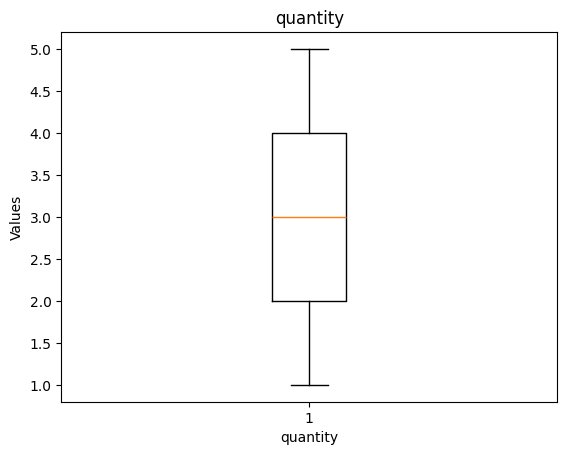

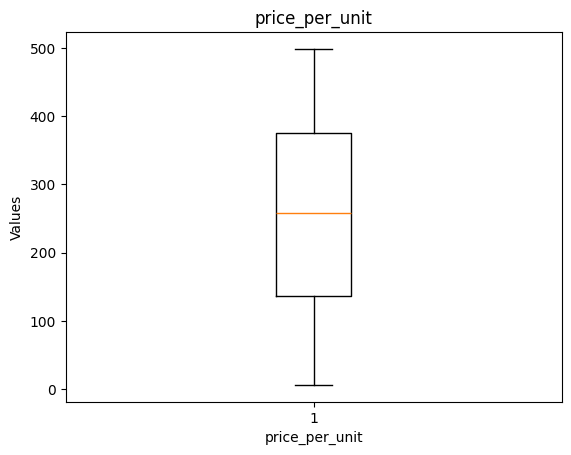

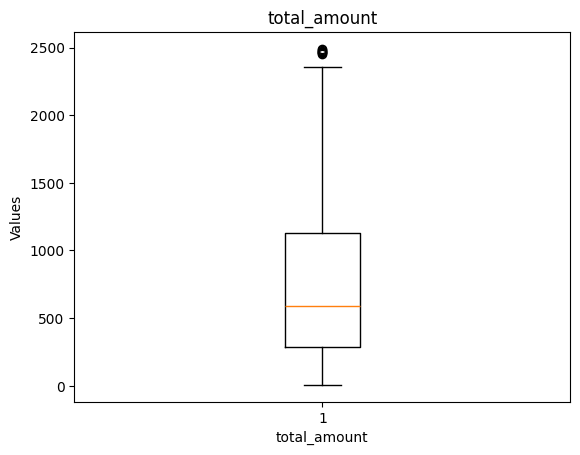

In [ ]:
### Task 4.3: Visualize Outliers
# Create box plots for the three numerical variables to visualize outliers.
print('='*60)
print("Create box plots for the three numerical variables to visualize outliers")
# print('='*60)
cols=['quantity','price_per_unit','total_amount']
print("Box plots help to visually identify outliers in the data")
print("Some values lie outside the bounds indicating outliers")
for col in cols:
    print("="*40)
    plt.figure()

    plt.boxplot(df[col], showfliers=True)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Values")
    plt.show()
  #Y-axis shows the actual data values

In [1]:
# **Question:** Should you remove these outliers? Why or why not?
# ```
# [Your reasoning here]
# ```
print('='*60)
print("Question: Should you remove these outliers? Why or why not?")

print("No, outliers should not be removed directly")
print("Some outliers can be real values and not mistakes")
print("Removing them may change the results")
print("Outliers should be checked first before removing")

Question: Should you remove these outliers? Why or why not?
No, outliers should not be removed directly
Some outliers can be real values and not mistakes
Removing them may change the results
Outliers should be checked first before removing


Create histograms :


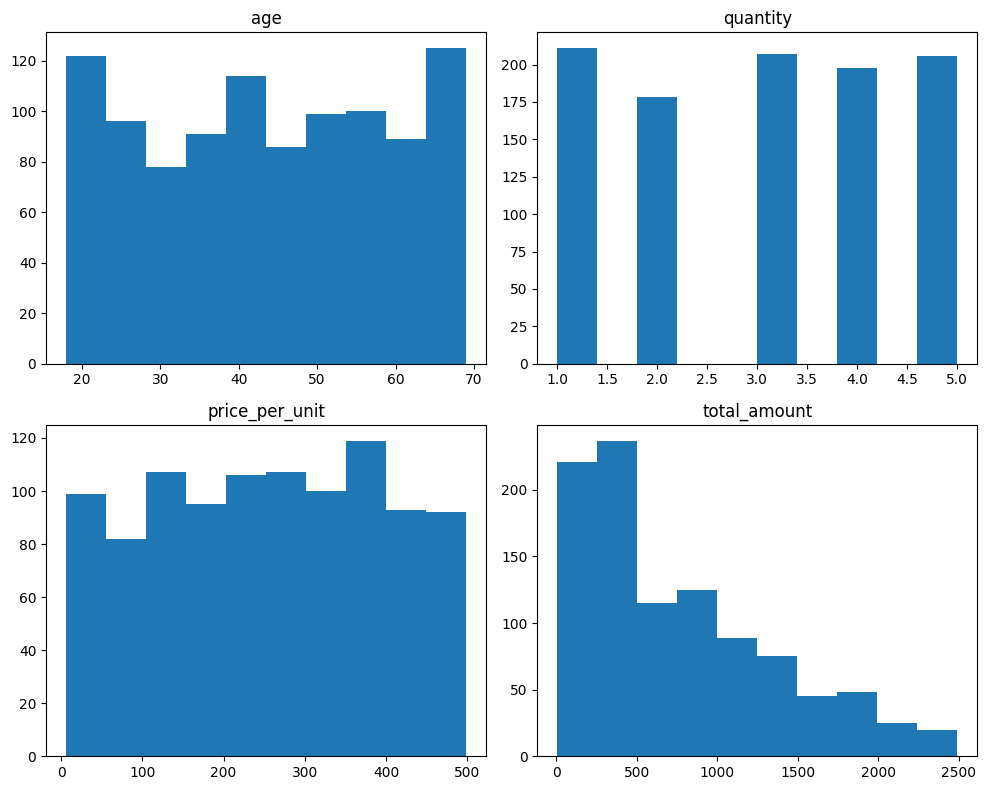

In [ ]:

# ## Part 5: Distribution Analysis (25 points)

# ### Task 5.1: Create Histograms
# Create histograms for:
# - age
# - quantity
# - price_per_unit
# - total_amount

# Arrange them in a 2×2 grid.
print('='*60)

print("Create histograms :")
print('='*60)
cols=['age','quantity','price_per_unit','total_amount']
plt.figure(figsize=(10,8))
i=1
for col in cols:

    plt.subplot(2,2,i)
    plt.hist(df[col])
    plt.title(col)
    i=i+1

plt.tight_layout()
plt.show()



In [2]:
# ### Task 5.2: Interpret Distributions
# For each variable, describe:
# - Is it normally distributed?
# - Is it skewed (left or right)?
# - Are there any unusual patterns?

# **Your interpretations:**
# ```
# Age: [Your interpretation]

# Quantity: [Your interpretation]

# Price per Unit: [Your interpretation]

# Total Amount: [Your interpretation]
# ```


print('='*60)
print("For each variable, describing:")
print('- Is it normally distributed?')
print('- Is it skewed (left or right)?')
print('- Are there any unusual patterns?')
print('='*60)
print("my interpretations:")
print('='*60)
print("Age: [my interpretation]")
print("Age is almost normally distributed")
print("Skewness is very close to zero")
print("Most ages are spread in the middle")
print("It looks almost normal")
print("No strange pattern seen")
print('='*60)
print("Quantity: [my interpretation]")

print("Quantity values are mostly between 1 and 5")
print("Distribution is almost symmetric")
print("Customers usually buy similar number of items")

print('='*60)
print("Price per Unit: [my interpretation]")
print("Prices are spread across the range")
print("It looks nearly normal")
print("No unusual pattern in prices")

print('='*60)
print("Total Amount: [my interpretation]")
print("Total amount is slightly right skewed")
print("Some transactions have very high values")
print("This happens when price and quantity are both high")

print('='*60)

For each variable, describing:
- Is it normally distributed?
- Is it skewed (left or right)?
- Are there any unusual patterns?
my interpretations:
Age: [my interpretation]
Age is almost normally distributed
Skewness is very close to zero
Most ages are spread in the middle
It looks almost normal
No strange pattern seen
Quantity: [my interpretation]
Quantity values are mostly between 1 and 5
Distribution is almost symmetric
Customers usually buy similar number of items
Price per Unit: [my interpretation]
Prices are spread across the range
It looks nearly normal
No unusual pattern in prices
Total Amount: [my interpretation]
Total amount is slightly right skewed
Some transactions have very high values
This happens when price and quantity are both high


In [ ]:
# ### Task 5.3: Test for Normality
# Use the Shapiro-Wilk test to formally test if the distributions are normal.
#  (p-value > 0.05 suggests normal distribution)

print("Use the Shapiro-Wilk test to formally test if the distributions are normal.")
print("(p-value > 0.05 suggests normal distribution)")
cols=['age','quantity','price_per_unit','total_amount']

for col in cols:
    print('='*40)
    print("Column:",col)
    stat,p=shapiro(df[col])
    print("Test statistic:",stat)
    print("p-value:",p)

    if p>0.05:
        print("Data looks normally distributed")
    else:
        print("Data is not normally distributed")


Use the Shapiro-Wilk test to formally test if the distributions are normal.
(p-value > 0.05 suggests normal distribution)
Column: age
Test statistic: 0.9530430147963976
p-value: 2.4137263069831215e-17
Data is not normally distributed
Column: quantity
Test statistic: 0.8845774585891918
p-value: 1.2283921224490606e-26
Data is not normally distributed
Column: price_per_unit
Test statistic: 0.9585125544736147
p-value: 3.130169585046052e-16
Data is not normally distributed
Column: total_amount
Test statistic: 0.9099477288871515
p-value: 7.36526243451903e-24
Data is not normally distributed


In [ ]:

## Part 6: Correlation Analysis (20 points)

# ### Task 6.1: Calculate Correlation Matrix
# Calculate the correlation matrix for numerical variables (age, quantity, price_per_unit, total_amount).
print('='*60)
print("Calculate the correlation matrix for numerical variables (age, quantity, price_per_unit, total_amount)")
cols=['age','quantity','price_per_unit','total_amount']
corr=df[cols].corr()
print(corr)

print('='*60)



Calculate the correlation matrix for numerical variables (age, quantity, price_per_unit, total_amount)
                     age  quantity  price_per_unit  total_amount
age             1.000000 -0.026154       -0.031142     -0.038733
quantity       -0.026154  1.000000       -0.001153      0.631336
price_per_unit -0.031142 -0.001153        1.000000      0.701700
total_amount   -0.038733  0.631336        0.701700      1.000000


Create a heatmap to visualize the correlation matrix with:
- Annotations showing correlation values
- Appropriate color scheme
- Proper title


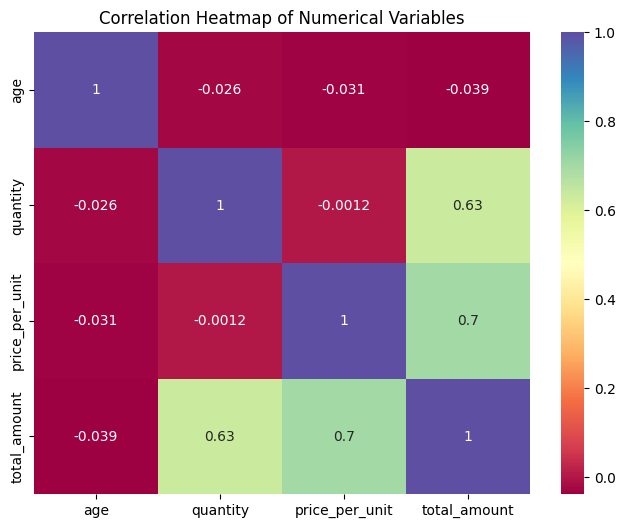

In [ ]:

### Task 6.2: Visualize Correlations
# Create a heatmap to visualize the correlation matrix with:
# - Annotations showing correlation values
# - Appropriate color scheme
# - Proper title

print('='*60)
print("Create a heatmap to visualize the correlation matrix with:")
print('- Annotations showing correlation values')
print('- Appropriate color scheme')
print('- Proper title')

cols=['age','quantity','price_per_unit','total_amount']
corr=df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='Spectral')
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()
print('='*60)


In [ ]:
# ### Task 6.3: Identify Strong Correlations
# Identify and list all pairs of variables with correlation coefficient |r| > 0.5



# **Question:** What does the correlation between total_amount and quantity tell you? Is this expected?
# ```
# [Your explanation here]
# ```
print('='*60)
print("Identify and list all pairs of variables with correlation coefficient |r| > 0.5")
cols=['age','quantity','price_per_unit','total_amount']
corr=df[cols].corr()

for i in range(len(cols)):
    for j in range(i+1,len(cols)):
        r=corr.iloc[i,j]
        if abs(r)>0.5:
            print(cols[i],"and",cols[j],"=",r)

print('='*60)
print("Question: What does the correlation between total_amount and quantity tell you? Is this expected?")
print("There is a strong positive correlation between total_amount and quantity")
print("This means when quantity increases, total_amount also increases")
print('='*60)


Identify and list all pairs of variables with correlation coefficient |r| > 0.5
quantity and total_amount = 0.6313356783620637
price_per_unit and total_amount = 0.7016997171853888
Question: What does the correlation between total_amount and quantity tell you? Is this expected?
There is a strong positive correlation between total_amount and quantity
This means when quantity increases, total_amount also increases


Create a bar chart showing the distribution of transactions across product categories


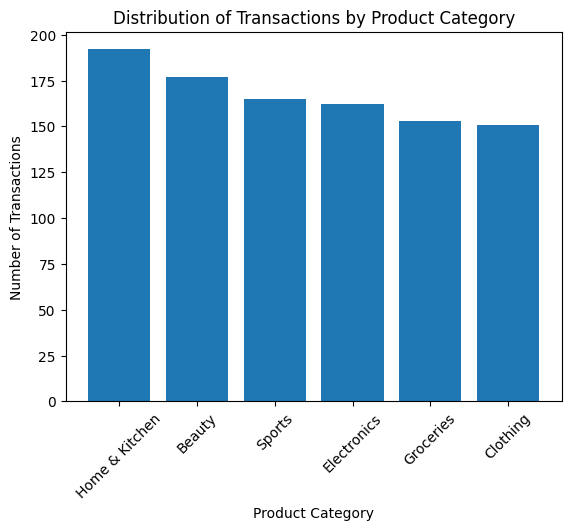

In [ ]:
# ## Part 7: Categorical Analysis (25 points)

# ### Task 7.1: Product Category Visualization
# Create a bar chart showing the distribution of transactions across product categories.
print('='*60)
print("Create a bar chart showing the distribution of transactions across product categories")
cat_count=df['product_category'].value_counts()

plt.figure()
plt.bar(cat_count.index,cat_count.values)
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Transactions by Product Category")
plt.xticks(rotation=45)
plt.show()
print('='*60)

Create a pie chart showing the gender distribution in the dataset


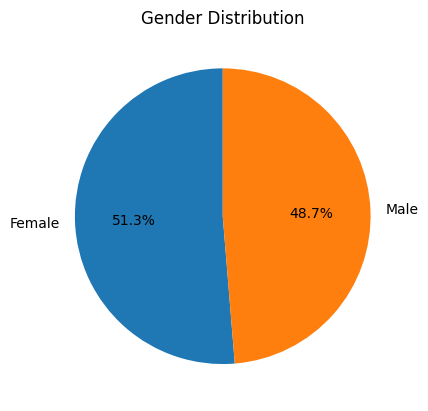

In [ ]:


### Task 7.2: Gender Distribution
# Create a pie chart showing the gender distribution in the dataset.
print('='*60)
print("Create a pie chart showing the gender distribution in the dataset")
gender_count=df['gender'].value_counts()

plt.figure()
plt.pie(gender_count,labels=gender_count.index,autopct='%1.1f%%',startangle=90)
plt.title("Gender Distribution")
plt.show()
print('='*60)

Task 7.3: Average Purchase by Category
Calculate and visualize the average purchase amount for each product category using a bar chart
product_category
Beauty            720.886893
Clothing          794.575629
Electronics       781.015741
Groceries         722.960458
Home & Kitchen    740.101250
Sports            832.730909
Name: total_amount, dtype: float64


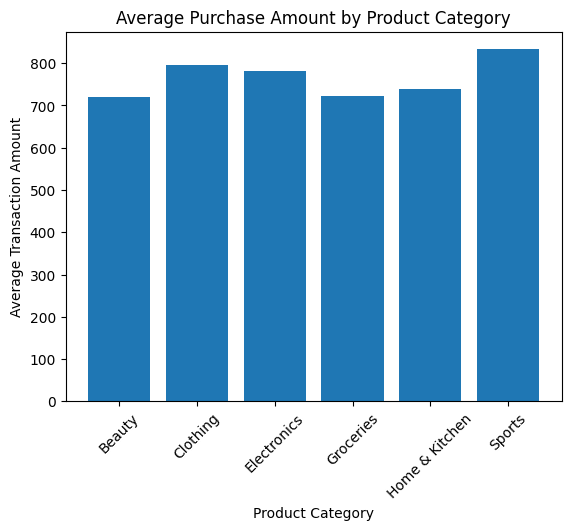

Question: Which product category has the highest average transaction value? What might explain this?
sports has highest average transaction value
sports items are usually costly


In [ ]:
# ### Task 7.3: Average Purchase by Category
# Calculate and visualize the average purchase amount for each product category using a bar chart.



# **Question:** Which product category has the highest average transaction value? What might explain this?
# ```
# [Your analysis here]
# ```
print('='*60)
print("Task 7.3: Average Purchase by Category")
print("Calculate and visualize the average purchase amount for each product category using a bar chart")
avg_amount=df.groupby('product_category')['total_amount'].mean()
print(avg_amount)

plt.figure()
plt.bar(avg_amount.index,avg_amount.values)
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Amount")
plt.title("Average Purchase Amount by Product Category")
plt.xticks(rotation=45)
plt.show()
print('='*60)
print("Question: Which product category has the highest average transaction value? What might explain this?")
print("sports has highest average transaction value")
print("sports items are usually costly")
print('='*60)


Create a scatter plot showing the relationship between price_per_unit (x-axis) and quantity (y-axis)


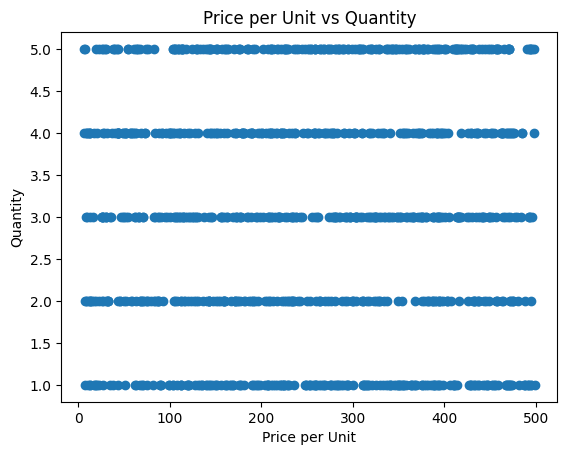

Question: What relationship do you observe between price and quantity purchased?
There is no strong relationship between price and quantity purchased
Customers buy similar quantities across different price ranges


In [ ]:
## Part 8: Bivariate Analysis (25 points)

# ### Task 8.1: Scatter Plot Analysis
# Create a scatter plot showing the relationship between price_per_unit (x-axis) and quantity (y-axis).

# **Question:** What relationship do you observe between price and quantity purchased?
# ```
# [Your observation here]
# ```
print('='*60)
print("Create a scatter plot showing the relationship between price_per_unit (x-axis) and quantity (y-axis)")
plt.figure()
plt.scatter(df['price_per_unit'],df['quantity'])
plt.xlabel("Price per Unit")
plt.ylabel("Quantity")
plt.title("Price per Unit vs Quantity")
plt.show()
print("Question: What relationship do you observe between price and quantity purchased?")
print("There is no strong relationship between price and quantity purchased")
print("Customers buy similar quantities across different price ranges")
print('='*60)


Create a scatter plot showing age vs total_amount, with different colors for each gender


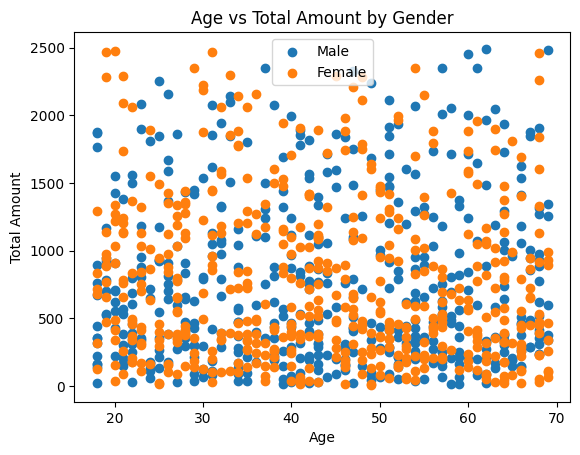

In [ ]:

### Task 8.2: Age vs Total Amount by Gender
# Create a scatter plot showing age vs total_amount, with different colors for each gender.
print('='*60)
print("Create a scatter plot showing age vs total_amount, with different colors for each gender")
plt.figure()

male=df[df['gender']=='Male']
female=df[df['gender']=='Female']

plt.scatter(male['age'],male['total_amount'],label='Male')
plt.scatter(female['age'],female['total_amount'],label='Female')

plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.title("Age vs Total Amount by Gender")
plt.legend()
plt.show()
print('='*60)


Create a box plot showing the distribution of total_amount for each product_category


/tmp/ipython-input-267420664.py:15: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



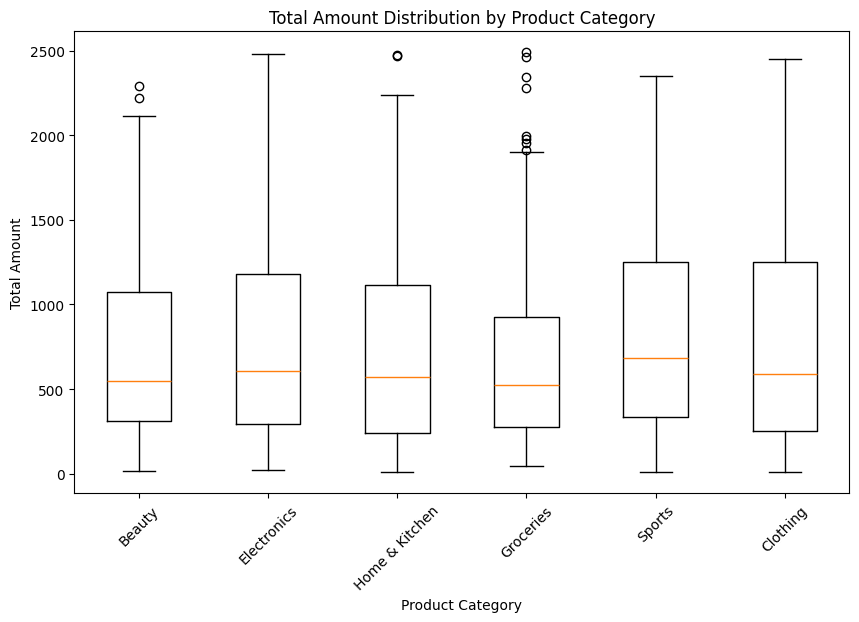

Question: Which category shows the most variation in transaction amounts?
Clothing category shows the most variation
The box and whiskers are wider for clothing
This shows transaction amounts vary more in this category


In [ ]:

### Task 8.3: Box Plot by Category
# Create a box plot showing the distribution of total_amount for each product_category.



# **Question:** Which category shows the most variation in transaction amounts?
# ```
# [Your answer here]
# ```

print('='*60)
print("Create a box plot showing the distribution of total_amount for each product_category")

plt.figure(figsize=(10,6))
plt.boxplot(
    [df[df['product_category']==cat]['total_amount'] for cat in df['product_category'].unique()],
    labels=df['product_category'].unique()
)
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.title("Total Amount Distribution by Product Category")
plt.xticks(rotation=45)
plt.show()

print('='*60)
print("Question: Which category shows the most variation in transaction amounts?")
print("Clothing category shows the most variation")
print("The box and whiskers are wider for clothing")
print("This shows transaction amounts vary more in this category")
print('='*60)



In [ ]:

## Part 9: Time Series Analysis (20 points)

# ### Task 9.1: Extract Date Components
# Extract the following from the date column:
# - year
# - month
# - day
# - day_of_week (name of the day)
print('='*60)
print("Extract the following from the date column:")


df['year']=df['date'].dt.year
df['month']=df['date'].dt.month
df['day']=df['date'].dt.day
df['day_of_week']=df['date'].dt.day_name()

print(df[['date','year','month','day','day_of_week']].head())
print('='*60)



Extract the following from the date column:
        date  year  month  day day_of_week
0 2024-06-19  2024      6   19   Wednesday
1 2024-02-03  2024      2    3    Saturday
2 2024-01-26  2024      1   26      Friday
3 2024-05-24  2024      5   24      Friday
4 2024-03-17  2024      3   17      Sunday


Calculate total sales for each day and create a line plot showing the daily sales trend
date
2024-01-01    3408.54
2024-01-02    1290.84
2024-01-03    5296.86
2024-01-04    2846.06
2024-01-05    5653.72
Name: total_amount, dtype: float64


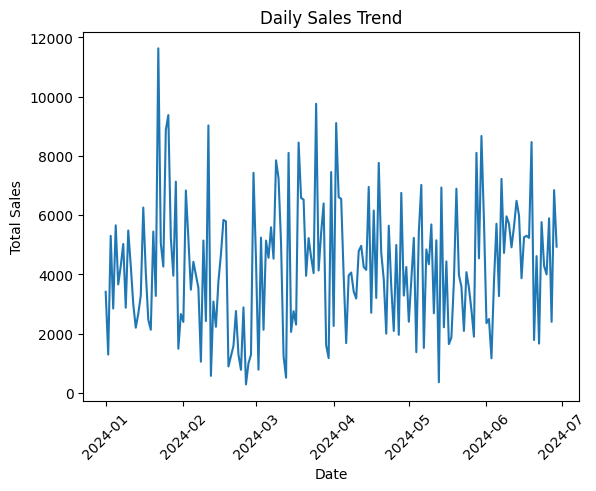

In [ ]:

### Task 9.2: Daily Sales Trend
#Calculate total sales for each day and create a line plot showing the daily sales trend.

print('='*60)
print("Calculate total sales for each day and create a line plot showing the daily sales trend")
daily_sales=df.groupby('date')['total_amount'].sum()
print(daily_sales.head())

plt.figure()
plt.plot(daily_sales.index,daily_sales.values)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Daily Sales Trend")
plt.xticks(rotation=45)
plt.show()
print('='*60)


Calculate and visualize total sales by day of week using a bar chart
day_of_week
Friday       124750.45
Monday       113172.07
Saturday      87538.62
Sunday       116913.96
Thursday     110009.94
Tuesday      101647.20
Wednesday    110183.20
Name: total_amount, dtype: float64


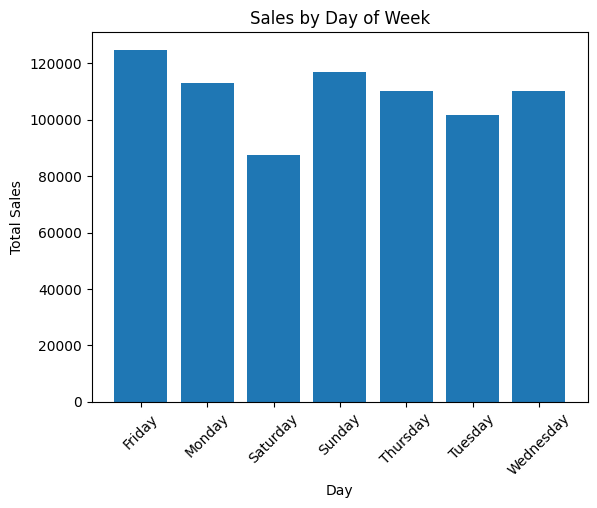

Question: Are there any patterns in sales across different days of the week?
Sales are highest on Friday
Sales are lowest on Saturday
Weekdays generally have higher sales than weekends


In [ ]:
### Task 9.3: Sales by Day of Week
# Calculate and visualize total sales by day of week using a bar chart.


# **Question:** Are there any patterns in sales across different days of the week?
# ```
# [Your observation here]
# ```
print('='*60)
print("Calculate and visualize total sales by day of week using a bar chart")

df['day_of_week']=df['date'].dt.day_name()

sales=df.groupby('day_of_week')['total_amount'].sum()
print(sales)

plt.figure()
plt.bar(sales.index,sales.values)
plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()
print('='*60)
print("Question: Are there any patterns in sales across different days of the week?")

print("Sales are highest on Friday")
print("Sales are lowest on Saturday")
print("Weekdays generally have higher sales than weekends")
print('='*60)



In [ ]:
# ## Part 10: Summary Report (20 points)

# ### Task 10.1: Key Findings
# Write a comprehensive summary report including:

# **Dataset Overview:**
# - Total number of transactions
# - Date range covered
# - Number of unique customers
# - Number of product categories

# ```
# [Your summary here]
# ```

# **Customer Demographics:**
# - Average customer age
# - Age range
# - Gender distribution

# ```
# [Your summary here]
# ```

# **Transaction Metrics:**
# - Average transaction value
# - Median transaction value
# - Total revenue
# - Average quantity per transaction

# ```
# [Your summary here]
# ```

# **Product Insights:**
# - Most popular category
# - Highest value category
# - Average price per unit

# ```
# [Your summary here]
# ```

# **Data Quality Issues:**
# - What issues did you find?
# - How did you address them?
# - Were there any limitations?

# ```
# [Your summary here]
# ```

# **Top 3 Business Insights:**
# List three actionable insights from your analysis.

# ```
# 1. [First insight]

# 2. [Second insight]

# 3. [Third insight]


print('='*60)
print("Dataset Overview:")

print("The dataset contains 1000 transactions")
print("The date range covers transactions from January 2024 to June 2024")
print("There are 1000 unique customers")
print("There are 6 product categories")
print('='*60)
print("Customer Demographics:")
print("Average customer age is around 44 years")
print("Age varies from 18 to 69")
print("Male and female customers are almost equal")
print('='*60)
print("Transaction Metrics:")
print("Average transaction value is about 764")
print("Median transaction value is around 587")
print("Total revenue is calculated from total_amount column")
print("On average customers buy about 3 items per transaction")
print('='*60)
print("Product Insights:")
print("Home and Kitchen category has the most transactions")
print("Sports category has the highest average transaction value")
print("Average price per unit is around 254")
print('='*60)
print("Data Quality Issues:")

print("No missing values were found")
print("No duplicate records were present")
print("Overall data quality is good")
print("The dataset covers only a six-month period,")
print('='*60)
print("Top 3 Business Insights:")
print("1. Sports products generate higher value transactions")
print("2. Weekday sales are higher compared to weekend sales")
print("3. Customers usually buy similar quantities regardless of price")
print('='*60)



Dataset Overview:
The dataset contains 1000 transactions
The date range covers transactions from January 2024 to June 2024
There are 1000 unique customers
There are 6 product categories
Customer Demographics:
Average customer age is around 44 years
Age varies from 18 to 69
Male and female customers are almost equal
Transaction Metrics:
Average transaction value is about 764
Median transaction value is around 587
Total revenue is calculated from total_amount column
On average customers buy about 3 items per transaction
Product Insights:
Home and Kitchen category has the most transactions
Sports category has the highest average transaction value
Average price per unit is around 254
Data Quality Issues:
No missing values were found
No duplicate records were present
Overall data quality is good
Top 3 Business Insights:
1. Sports products generate higher value transactions
2. Weekday sales are higher compared to weekend sales
3. Customers usually buy similar quantities regardless of price


In [ ]:
# ## Additional Challenge (Optional Bonus: +10 points)

# Perform a more advanced analysis of your choice, such as:
# - Customer segmentation based on purchasing behavior
# - Identify top-spending customer IDs
# - Analyze which age groups prefer which product categories
# - Create an interactive visualization using plotly
# - Perform statistical hypothesis testing

print('='*60)
print("Customer segmentation based on purchasing behavior")
cust_spend=df.groupby('customer_id')['total_amount'].sum()

segment={}
for cid in cust_spend.index:
    if cust_spend[cid]>2000:
        segment[cid]='High spender'
    elif cust_spend[cid]>1000:
        segment[cid]='Medium spender'
    else:
        segment[cid]='Low spender'

seg_df=pd.DataFrame(list(segment.items()),columns=['customer_id','segment'])
print(seg_df.head())

print('='*60)
print("Identify top-spending customer IDs")
total_spend=df.groupby('customer_id')['total_amount'].sum()
total_spend=total_spend.sort_values(ascending=False)

print("Top 5 spending customers:")
print(total_spend.head())

print('='*60)
print("Analyze which age groups prefer which product categories")
df['age_group']=pd.cut(
    df['age'],
    bins=[0,18,30,45,60,100],
    labels=['<18','18-30','30-45','45-60','60+']
)

age_pref=df.groupby(['age_group','product_category'])['total_amount'].sum()
print(age_pref.head(10))

print('='*60)
print("Create an interactive visualization using plotly")

fig=px.bar(
    df,
    x='product_category',
    y='total_amount',
    title='Total Amount by Product Category',
    color='product_category'
)

fig.show()

print('='*60)
print("Perform statistical hypothesis testing")

male_sales=df[df['gender']=='Male']['total_amount']
female_sales=df[df['gender']=='Female']['total_amount']

t_stat,p_value=ttest_ind(male_sales,female_sales)

print("T statistic:",t_stat)
print("P value:",p_value)

if p_value>0.05:
    print("There is no significant difference in spending between males and females")
else:
    print("There is a significant difference in spending between males and females")

print('='*60)

Customer segmentation based on purchasing behavior
   customer_id         segment
0         1000     Low spender
1         1001    High spender
2         1004    High spender
3         1007  Medium spender
4         1008     Low spender
Identify top-spending customer IDs
Top 5 spending customers:
customer_id
1098    6296.97
1775    5710.27
1565    4720.54
1735    4585.82
1681    4348.20
Name: total_amount, dtype: float64
Analyze which age groups prefer which product categories
age_group  product_category
<18        Beauty               2545.89
           Clothing             4999.01
           Electronics          4148.68
           Groceries               0.00
           Home & Kitchen       1245.99
           Sports               1054.82
18-30      Beauty              36845.64
           Clothing            23630.22
           Electronics         36088.57
           Groceries           29535.19
Name: total_amount, dtype: float64
Create an interactive visualization using plotly


/tmp/ipython-input-3915085074.py:42: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Perform statistical hypothesis testing
T statistic: -0.06846033210722953
P value: 0.9454329098052636
There is no significant difference in spending between males and females


In [ ]:
df.describe()


,transaction_id,date,customer_id,age,quantity,price_per_unit,total_amount,year,month,day
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.000000,1000.000000
mean,500.500000,2024-04-02 15:46:04.800000,1503.929000,43.713000,3.010000,253.968830,764.215440,2024.0,3.571000,15.703000
min,1.000000,2024-01-01 00:00:00,1000.000000,18.000000,1.000000,6.000000,7.490000,2024.0,1.000000,1.000000
25%,250.750000,2024-02-16 00:00:00,1242.750000,31.000000,2.000000,135.875000,284.925000,2024.0,2.000000,8.000000
50%,500.500000,2024-04-03 00:00:00,1505.000000,43.000000,3.000000,258.420000,587.100000,2024.0,4.000000,16.000000
75%,750.250000,2024-05-19 00:00:00,1757.250000,57.000000,4.000000,375.955000,1130.077500,2024.0,5.000000,23.000000
max,1000.000000,2024-06-29 00:00:00,1998.000000,69.000000,5.000000,498.820000,2490.750000,2024.0,6.000000,31.000000
std,288.819436,NaN,289.998108,15.094651,1.430366,140.094358,599.301174,0.0,1.711107,8.631413


In [ ]:
# ## Submission Checklist

# Before submitting, ensure you have:
# - Completed all tasks with working code
# - Answered all questions
# - Generated all required visualizations
# - Written clear interpretations and insights
# - Tested your code to ensure it runs without errors
# - Saved all visualizations as PNG files
# - Completed the summary report

# ## Evaluation Criteria

# Your submission will be evaluated on:
# - **Code Quality (20%)**: Clean, well-commented, efficient code
# - **Correctness (30%)**: Accurate implementation of analysis techniques
# - **Visualization (20%)**: Clear, informative, well-labeled plots
# - **Interpretation (20%)**: Thoughtful analysis and insights
# - **Completeness (10%)**: All tasks attempted and questions answered

# **Total Points: 210**


